# SHOW — 7 essential (+2 optional) · presentation figure deck

**One notebook that renders the nine figures chosen for the slides**, each pulled from the
pipeline stage where it is defined. The story arc is: *a single game is ambiguous (R2) →
but a **player** (many games) is a sharp fingerprint (R1, R3) → so “how many games?” has a
practical answer (R4) → yet that fingerprint is **deck-entangled**, not portable (R5, R6, R6b) →
here is the first partial fix (R6c).*

### How this deck is built
All figures render from **one parse** using the **V4 parser**
([`V4/playstyle_log_parse_v4.py`](V4/playstyle_log_parse_v4.py)), which is a strict superset —
it emits every V2, V3-trajectory/tell and V4 normalized/universal column, for **both** deck
families (`RenoKazakusMage`, `AggroPirateWarrior`). Each figure is then drawn with the *feature
set of the version it came from*, so it matches that version's own notebook:

| # | Figure (exact title in code) | Render from | Feature set | Why it earns a slide |
|---|------------------------------|-------------|-------------|----------------------|
| **R1** | Play-style fingerprints — per-style mean of each metric (z-score) | **V2**, Mage | 11 V2 metrics | The one interpretable “what a style looks like” visual |
| **R2** | §5 Per-game: PCA + t-SNE + KMeans confusion (ARI≈0.09) | **V2**, Mage | 11 V2 metrics | Proves one game overlaps — sets up the problem |
| **R3 ★** | §6 ARI-vs-N curve + fingerprint clouds (N=120) + confusion | **V2**, Mage | 11 V2 metrics | The headline: 0.09 → 0.99 |
| **R4** | Q1 · accuracy vs #games (per style) | **V3-full**, Mage | 29 (V2 + trajectory + tells) | The practical answer (~30 games → 90%) |
| **R5** | Within-deck vs cross-deck transfer (bar) | **V4**, both | 3 feature sets | The open problem: cross-deck ARI → ~0 (LDA, N=10) |
| **R6** | Cross-deck per-style recall (heatmap) | **V4**, both | agnostic (29) | Only fatigue transfers |
| **R6b** | Cross-deck aggregate accuracy vs games pooled | **V4**, both | agnostic (29) | The clincher: pooling does *nothing* cross-deck → it's bias, not noise |
| **R7** *(opt)* | RF feature importance | **V2**, Mage | 11 V2 metrics | Which metrics carry style — support, not spine |
| **R6c** *(opt)* | Aggregated cross-deck: raw vs deck-normalised | **V4**, both | agnostic (29) | First partial fix (ARI ~0.22 → ~0.44) — future-work traction |

> **Provenance of the code.** R1/R2/R3/R7 are lifted from
> [`V2/…_v2.ipynb`](V2/playstyle_log_distribution_analysis_RenoKazakusMage_v2.ipynb) (§3/§5/§5b/§6);
> R4 from [`V3/…_v3_full.ipynb`](V3/playstyle_log_distribution_analysis_RenoKazakusMage_v3_full.ipynb) (§8);
> R5/R6/R6b from [`V4/…_v4.ipynb`](V4/playstyle_log_distribution_analysis_RenoKazakusMage_v4.ipynb) (§9);
> R6c from the reviewer follow-up (Prof. Kokolo #3b, domain-shift correction).

## 0 · Setup — one parse feeds every figure

Imports the **V4 parser**, parses both deck families into `games_all`, and defines the three
feature sets plus the shared helpers (`X2/y2` = the standardised V2-Mage matrix used by
R1/R2/R3/R7, and `cluster_confusion` used by R2/R3). Uses the on-disk cache
`playstyle_log_metrics_v4_bothdecks.pkl` — delete it to force a re-parse of the raw logs.

In [96]:
import os, sys, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# --- anchor to the repo root regardless of the kernel CWD, then import the V4 parser ---
def _repo_root():
    """Nearest ancestor of the CWD holding both Log_Analysis/ and log/."""
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "Log_Analysis")) and os.path.isdir(os.path.join(d, "log")):
            return d
        if os.path.basename(d) == "Log_Analysis":
            return os.path.dirname(d)
        parent = os.path.dirname(d)
        if parent == d:
            raise FileNotFoundError("repo root with Log_Analysis/ and log/ not found from " + os.getcwd())
        d = parent
ROOT = _repo_root()
sys.path.insert(0, os.path.join(ROOT, "Log_Analysis", "V4"))
# The V4 parser is a SUPERSET: it emits every V2 + V3 (trajectory/tell) + V4 column,
# for BOTH deck families -> one parse can render figures from all three versions.
from playstyle_log_parse_v4 import (build_frames, BASE_DIR, DECKS,
    METRICS as V2_METRICS, TRAJ_METRICS, A_FEATURES, AGNOSTIC_FEATURES, RATIO_FEATURES)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

# stable order + one colour per play-style (used by every figure)
STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))

CACHE = os.path.join(BASE_DIR, "playstyle_log_metrics_v4_bothdecks.pkl")
games_all, cards_all, turns_all = build_frames(cache=CACHE, deck=DECKS)
games_all["style"] = pd.Categorical(games_all["style"], categories=STYLE_ORDER, ordered=True)

DECK_HOME  = "RenoKazakusMage"                              # "home" deck for the single-deck figures
games_mage = games_all[games_all["deck"] == DECK_HOME].copy()

# --- the three feature sets, each tagged with the version that defines it ---
FEATURES_V2 = list(V2_METRICS)                                            # 11  -> R1, R2, R3, R7
FEATURES_V3 = list(V2_METRICS) + list(TRAJ_METRICS) + list(A_FEATURES)    # 29  -> R4  (V3-full)
FEATURES_V4 = list(AGNOSTIC_FEATURES)                                     # 29  -> R5, R6, R6b, R6c

def standardize(df, feats):
    """Median-impute + z-score a feature block; return (X, y=style strings)."""
    from sklearn.preprocessing import StandardScaler
    Xr = df[feats].copy(); Xr = Xr.fillna(Xr.median())
    y  = df["style"].astype(str).values
    X  = StandardScaler().fit(Xr.values).transform(Xr.values)
    return X, y

# V2 (Mage) standardised matrix — shared by R1/R2/R3/R7
X2, y2 = standardize(games_mage, FEATURES_V2)

# map cluster ids -> styles (Hungarian on the contingency table) for readable confusion matrices
from scipy.optimize import linear_sum_assignment
def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster->style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

print(f"games_all {games_all.shape} | home deck '{DECK_HOME}' -> games_mage {games_mage.shape}")
print(f"feature-set sizes:  V2={len(FEATURES_V2)}  V3-full={len(FEATURES_V3)}  V4-agnostic={len(FEATURES_V4)}")
print("\ngames per deck/style:")
print(games_all.groupby(["deck", "style"], observed=True).size().to_string())

games_all (8992, 58) | home deck 'RenoKazakusMage' -> games_mage (4492, 58)
feature-set sizes:  V2=11  V3-full=29  V4-agnostic=29

games per deck/style:
deck                style   
AggroPirateWarrior  aggro       900
                    control     900
                    fatigue     900
                    midrange    900
                    ramp        900
RenoKazakusMage     aggro       900
                    control     898
                    fatigue     899
                    midrange    899
                    ramp        896


## R1 · Play-style fingerprints — per-style mean of each metric (z-score)

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §3 (cell `c3ca5a15`, heatmap half).
* **Why a slide:** the one interpretable *“what a style looks like”* visual — each column is a
  metric, each row a style, colour = how many σ that style sits from the 5-style average
  (annotations are the raw means). Read the red/blue bands: aggro = high face-attack & attacks/turn,
  fatigue = long games & high cards-in-hand, ramp = high mana, etc.
* **Note:** z-scored *across the 5 styles* so a subtle-but-consistent tell is as visible as a loud one.

,n_my_turns,avg_cards_in_hand,mana_eff,avg_card_cost,minion_fraction,face_attack_ratio,attacks_per_turn,enemy_minions_killed_per_turn,avg_board_minions,taken_dmg_per_turn,hp_per_turn
style,,,,,,,,,,,
aggro,6.820,5.416,0.566,3.056,0.439,0.839,0.183,0.022,0.058,5.589,0.536
control,9.939,4.490,0.722,3.322,0.517,0.651,0.474,0.185,0.153,3.497,0.314
fatigue,9.174,4.601,0.680,3.240,0.494,0.761,0.397,0.151,0.117,4.027,0.347
midrange,10.633,4.510,0.734,3.585,0.521,0.693,0.606,0.169,0.164,2.851,0.280
ramp,11.241,4.516,0.740,3.632,0.537,0.607,0.667,0.177,0.197,2.557,0.272


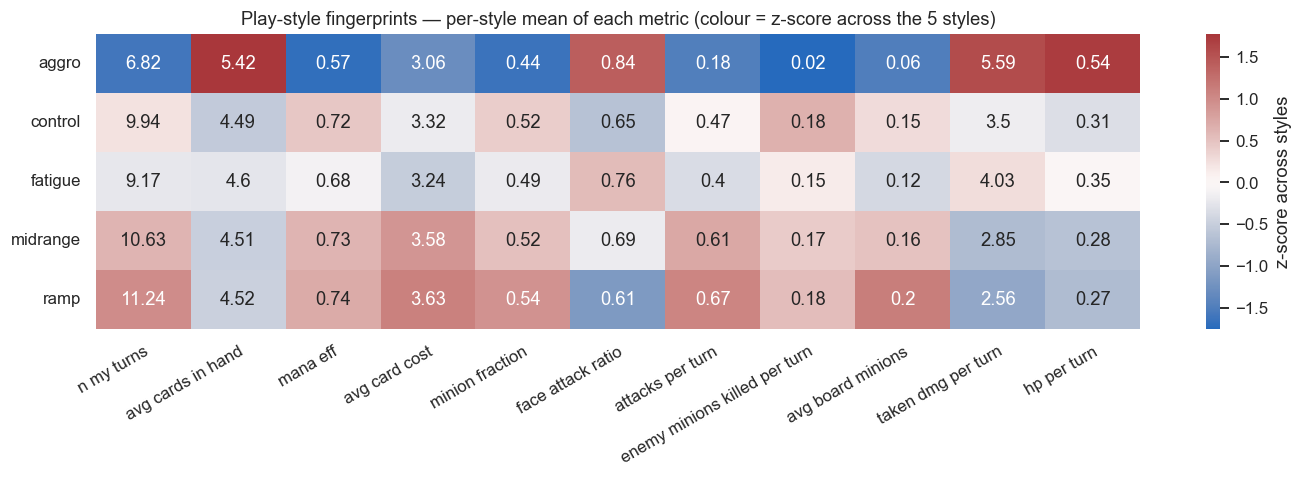

In [97]:
# R1 — Play-style fingerprints (V2, Mage, 11 metrics)
mean_tbl = games_mage.groupby("style", observed=True)[FEATURES_V2].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()
display(mean_tbl.round(3))
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across styles"})
ax.set_title("Play-style fingerprints — per-style mean of each metric (colour = z-score across the 5 styles)")
ax.set_ylabel("")                                              # 'style' axis title is redundant
# keep the 5 style names upright, and angle the long metric names so they don't collide/clip
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
ax.set_xticklabels([t.get_text().replace("_", " ") for t in ax.get_xticklabels()],
                   rotation=30, ha="right", rotation_mode="anchor")
fig.tight_layout(); plt.show()

## R2 · §5 Per-game: PCA + t-SNE + KMeans confusion (ARI ≈ 0.09)

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §5 (cell `290fb203`).
* **Why a slide:** it *sets up the problem*. At the **single-game** level the 5 styles mostly
  overlap — PCA and t-SNE show tangled point clouds and unsupervised KMeans(k=5) barely beats
  random (ARI ≈ 0.09). One game is not enough to name a style.
* **Reads with R3:** R2 is the "before" (one game), R3 is the "after" (pool games).

Per-game unsupervised clustering vs the 5 true styles
  KMeans : ARI=0.094  AMI=0.132  silhouette=0.137
  GMM    : ARI=0.074  AMI=0.105  silhouette=0.066


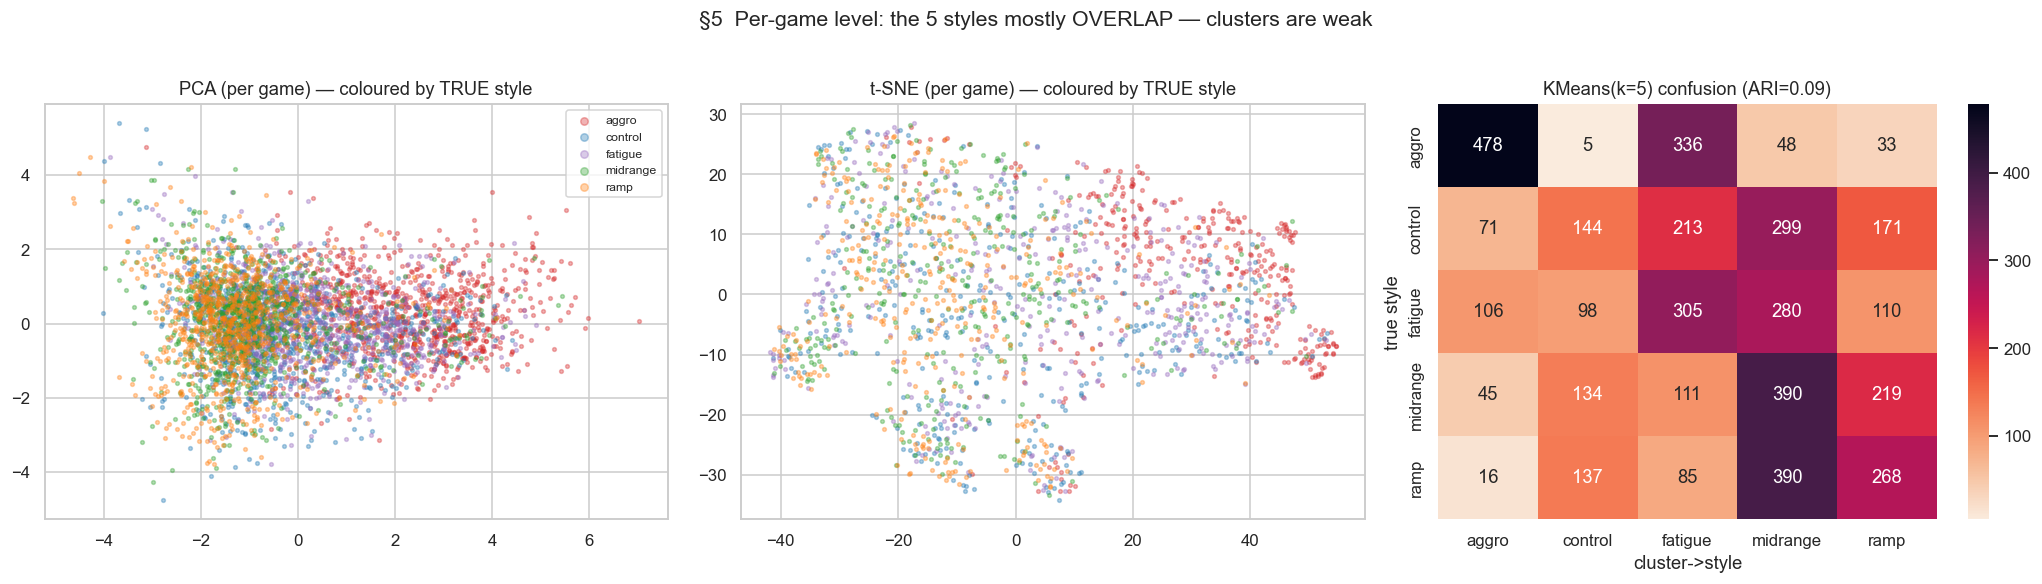

In [98]:
# R2 — §5 per-game projection & clustering (uses X2/y2 and cluster_confusion from setup)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score

pca = PCA(n_components=2, random_state=0).fit(X2)
P = pca.transform(X2)
rng = np.random.default_rng(0)
sub = rng.choice(len(X2), size=min(1800, len(X2)), replace=False)   # t-SNE on a subsample (speed)
T = TSNE(n_components=2, init="pca", perplexity=40, random_state=0).fit_transform(X2[sub])

km = KMeans(5, n_init=10, random_state=0).fit(X2)
gm = GaussianMixture(5, covariance_type="full", random_state=0).fit(X2)
km_lab, gm_lab = km.labels_, gm.predict(X2)

print("Per-game unsupervised clustering vs the 5 true styles")
for name, lab in [("KMeans", km_lab), ("GMM", gm_lab)]:
    print(f"  {name:7s}: ARI={adjusted_rand_score(y2, lab):.3f}  "
          f"AMI={adjusted_mutual_info_score(y2, lab):.3f}  silhouette={silhouette_score(X2, lab):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
for st in STYLE_ORDER:
    m = (y2 == st); ax[0].scatter(P[m, 0], P[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
    ms = (y2[sub] == st); ax[1].scatter(T[ms, 0], T[ms, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[0].set_title("PCA (per game) — coloured by TRUE style"); ax[0].legend(fontsize=8, markerscale=2)
ax[1].set_title("t-SNE (per game) — coloured by TRUE style")
cm, _ = cluster_confusion(y2, km_lab)
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"KMeans(k=5) confusion (ARI={adjusted_rand_score(y2, km_lab):.2f})")
for a in ax[:2]:
    a.set_xlabel(""); a.set_ylabel("")
fig.suptitle("§5  Per-game level: the 5 styles mostly OVERLAP — clusters are weak", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## R3 ★ · §6 ARI-vs-N curve + fingerprint clouds (N=120) + confusion

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §6 (cell `5cf70b12`).
* **Why a slide (the headline):** aggregate a *player* (N games averaged into one fingerprint)
  and the cluster–style ARI climbs from **≈ 0.09 at N=1 to ≈ 0.99 at N=120**. Left: ARI &
  silhouette vs N. Middle: the N=120 fingerprint clouds now split into five clean clusters.
  Right: the KMeans-vs-true confusion is almost diagonal. Same 11 metrics as R2 — the only thing
  that changed is *how many games* define the player.

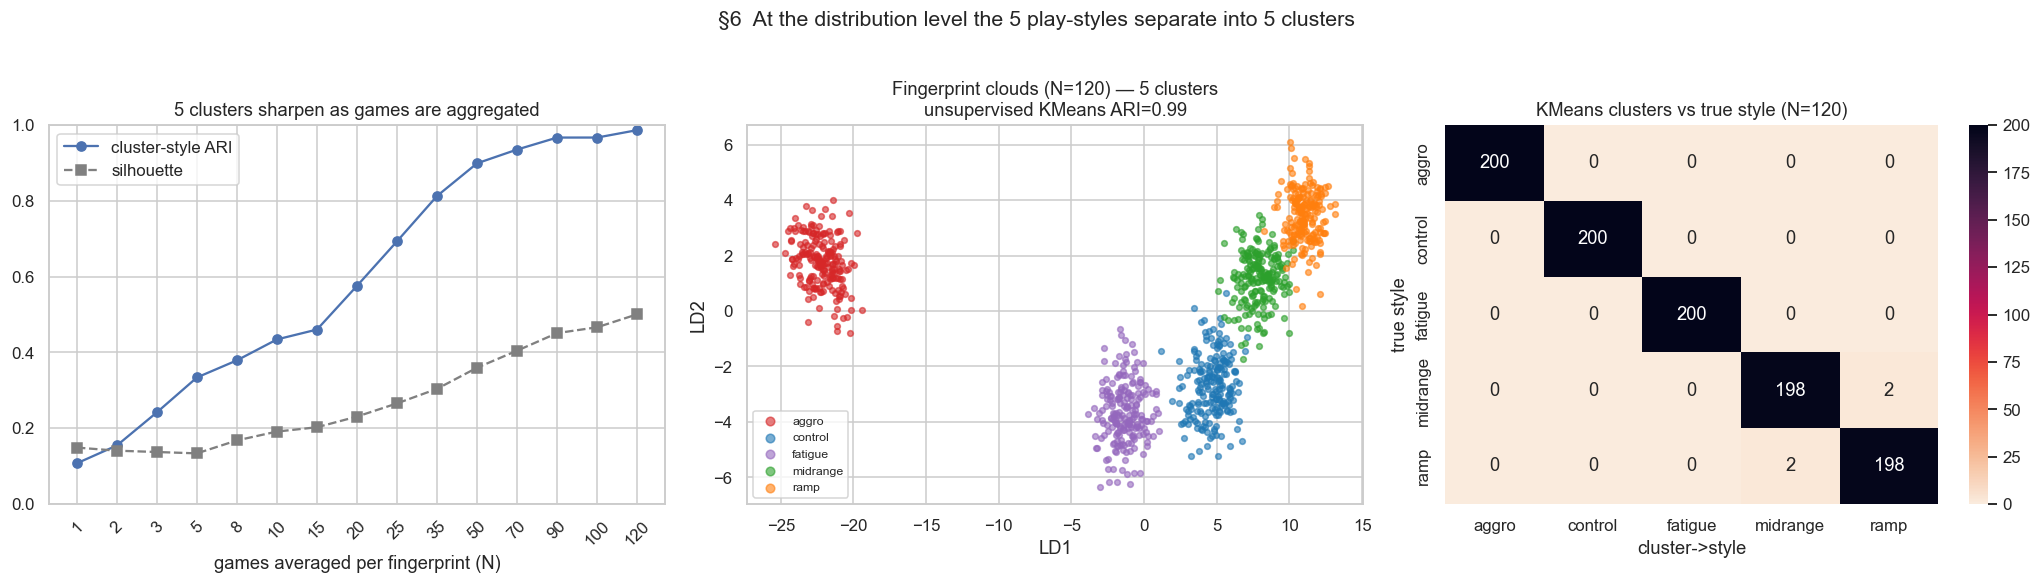

unsupervised KMeans(k=5) on N=120 fingerprints:  ARI=0.990


In [99]:
# R3 — §6 the 5 clusters emerge as games are aggregated (uses X2/y2, cluster_confusion)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def bootstrap_fingerprints(N, reps=150, seed=0):
    rng = np.random.default_rng(seed)
    rows, lab = [], []
    for st in STYLE_ORDER:
        a = X2[y2 == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(axis=0)); lab.append(st)
    return np.array(rows), np.array(lab)

# ARI of unsupervised KMeans(k=5) on the fingerprints, as a function of N
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
aris, sils = [], []
for N in Ns:
    Xb, yb = bootstrap_fingerprints(N)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab)); sils.append(silhouette_score(Xb, lab))

# a clean picture at a representative N
Xb, yb = bootstrap_fingerprints(120, reps=200)
labb = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
ari_b = adjusted_rand_score(yb, labb)
Lb = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
_xs = range(len(Ns))
ax[0].plot(_xs, aris, "o-", label="cluster-style ARI")
ax[0].plot(_xs, sils, "s--", color="gray", label="silhouette")
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(Ns, rotation=45)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_title("5 clusters sharpen as games are aggregated"); ax[0].legend(); ax[0].set_ylim(0, 1)
for st in STYLE_ORDER:
    m = (yb == st); ax[1].scatter(Lb[m, 0], Lb[m, 1], s=14, alpha=.6, color=STYLE_COLORS[st], label=st)
ax[1].set_title(f"Fingerprint clouds (N=120) — 5 clusters\nunsupervised KMeans ARI={ari_b:.2f}")
ax[1].legend(fontsize=8, markerscale=1.5); ax[1].set_xlabel("LD1"); ax[1].set_ylabel("LD2")
cmb, _ = cluster_confusion(yb, labb)
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title("KMeans clusters vs true style (N=120)")
fig.suptitle("§6  At the distribution level the 5 play-styles separate into 5 clusters", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
print(f"unsupervised KMeans(k=5) on N=120 fingerprints:  ARI={ari_b:.3f}")

## R4 · Q1 · accuracy vs #games (per style)

* **From:** V3-full · `RenoKazakusMage` · **29 features** (11 V2 + 13 trajectory + 5 Change-A tells)
  · source §8 (cell `74d23828`).
* **Why a slide:** the *practical* answer to “how many games do I need to name a player's style?”
  A held-out LDA trained on N-game fingerprints reaches **~90% around N ≈ 30** overall; the per-style
  curves show `aggro` is a near-giveaway from a single game while the value styles need pooling.
  The extra trajectory/tell features (vs R3's 11) lift the small-N accuracy.
* **Panels:** accuracy-vs-N per style · per-style accuracy heatmap across N · single-game confusion (Q2).

Smallest N (games averaged) to reach accuracy:
  overall (LDA) >= 80%: N = 15
  overall (LDA) >= 90%: N = 35
  per style >= 90%:  aggro: 2 | control: 35 | fatigue: 8 | midrange: 50 | ramp: 90

Single-game accuracy: 0.470  (chance 0.20)  -> aggro is a giveaway; the rest need pooling


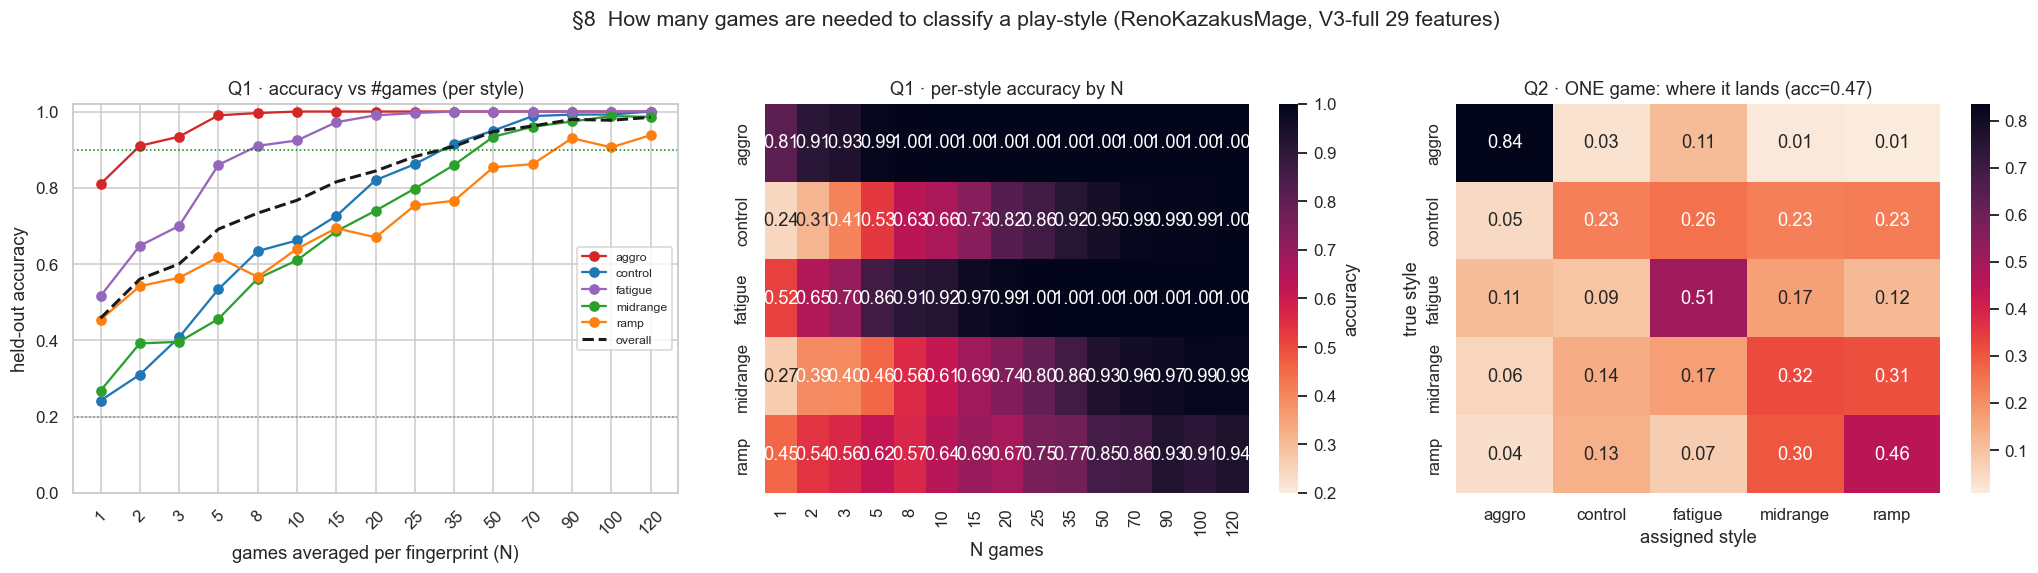

,overall (LDA),overall (centroid),aggro,control,fatigue,midrange,ramp
N,,,,,,,
1,0.458,0.416,0.810,0.242,0.516,0.268,0.454
2,0.560,0.502,0.910,0.310,0.648,0.392,0.542
3,0.600,0.560,0.934,0.408,0.700,0.396,0.564
5,0.692,0.630,0.990,0.534,0.860,0.456,0.618
8,0.734,0.695,0.996,0.634,0.910,0.562,0.566
10,0.767,0.717,1.000,0.662,0.924,0.610,0.640
15,0.816,0.772,1.000,0.726,0.972,0.686,0.694
20,0.844,0.812,1.000,0.820,0.990,0.740,0.670
25,0.882,0.832,1.000,0.862,0.996,0.798,0.754


In [100]:
# R4 — §8 Q1 accuracy vs #games, on the V3-full 29-feature set (Mage)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

FEATURES = FEATURES_V3   # V3-full: 11 V2 metrics + trajectory + Change-A tells (29)

# --- held-out 50/50 split within each style (disjoint games) ---
rng = np.random.default_rng(1)
G = games_mage.copy(); G[FEATURES] = G[FEATURES].fillna(G[FEATURES].median())
tr_idx, te_idx = [], []
for st in STYLE_ORDER:
    idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
    h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
tr, te = G.loc[tr_idx], G.loc[te_idx]
sc8 = StandardScaler().fit(tr[FEATURES].values)
Xtr, Xte = sc8.transform(tr[FEATURES].values), sc8.transform(te[FEATURES].values)
ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
teby = {s: Xte[yte == s] for s in STYLE_ORDER}
Cen  = np.vstack([trby[s].mean(0) for s in STYLE_ORDER])   # train fingerprint centroids = the 5 clusters

def make_fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

# --- Q1: accuracy vs N (LDA model; nearest-centroid for reference) ---
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
rows = []
for N in Ns:
    Xa, ya = make_fps(trby, N, 500, 10)
    lda = LinearDiscriminantAnalysis().fit(Xa, ya)
    Xb, yb = make_fps(teby, N, 500, 20)
    p_lda = lda.predict(Xb)
    p_nc  = (((Xb[:, None] - Cen[None]) ** 2).sum(2)).argmin(1)
    row = {"N": N, "overall (LDA)": (p_lda == yb).mean(), "overall (centroid)": (p_nc == yb).mean()}
    for si, s in enumerate(STYLE_ORDER):
        row[s] = (p_lda[yb == si] == si).mean()
    rows.append(row)
acc = pd.DataFrame(rows).set_index("N")

def first_N(col, thr):
    hit = acc.index[acc[col] >= thr]
    return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Smallest N (games averaged) to reach accuracy:")
for thr in (0.80, 0.90):
    print(f"  overall (LDA) >= {thr:.0%}: N = {first_N('overall (LDA)', thr)}")
print("  per style >= 90%:  " + " | ".join(f"{s}: {first_N(s, 0.90)}" for s in STYLE_ORDER))

# --- Q2: single held-out game, classified once each ---
lda1 = LinearDiscriminantAnalysis().fit(Xtr, ytr)
cm1 = confusion_matrix(yte, lda1.predict(Xte), labels=STYLE_ORDER, normalize="true")
print(f"\nSingle-game accuracy: {np.trace(cm1) / 5:.3f}  (chance 0.20)  -> aggro is a giveaway; the rest need pooling")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.3))
# panel 1: accuracy vs N
_xs = range(len(acc.index))
for s in STYLE_ORDER:
    ax[0].plot(_xs, acc[s], "o-", color=STYLE_COLORS[s], label=s)
ax[0].plot(_xs, acc["overall (LDA)"], "k--", lw=2, label="overall")
ax[0].axhline(0.2, color="gray", ls=":", lw=1); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(acc.index, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_ylabel("held-out accuracy"); ax[0].set_title("Q1 · accuracy vs #games (per style)"); ax[0].legend(fontsize=8)
# panel 2: per-style accuracy heatmap across N
hm = acc[STYLE_ORDER].T
sns.heatmap(hm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0.2, vmax=1.0, ax=ax[1],
            cbar_kws={"label": "accuracy"})
ax[1].set_title("Q1 · per-style accuracy by N"); ax[1].set_xlabel("N games"); ax[1].set_ylabel("")
# panel 3: single-game confusion
sns.heatmap(pd.DataFrame(cm1, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"Q2 · ONE game: where it lands (acc={np.trace(cm1)/5:.2f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("assigned style")
fig.suptitle("§8  How many games are needed to classify a play-style (RenoKazakusMage, V3-full 29 features)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
display(acc.style.format("{:.3f}").background_gradient(cmap="rocket_r", subset=STYLE_ORDER + ["overall (LDA)"])
        .set_caption("Held-out accuracy of an N-game fingerprint (V3-full features)"))

## R5 · Within-deck vs cross-deck transfer (bar)

* **From:** V4 · **both** deck families · source §9a (cell `v4xdeck_rf`).
* **Model / metric:** **LDA** on **N = 10-game fingerprints**, scored by **ARI** (adjusted Rand index
  of the predictions vs the true styles; chance = 0).
* **Why a slide (the open problem):** everything above lived on **one** deck. Train LDA on one deck and
  score the **other** and the agreement collapses toward chance — within-deck ARI ≈ 0.3–0.6 but
  cross-deck ARI ≈ 0. The AI's “style” is **entangled with the deck**, not a free-floating fingerprint.
* **The comparison:** *no* feature set rescues the transfer — cross-deck ARI stays near 0 for the
  deck-leaky V3-full set, the V4 agnostic set and the pure-ratio set alike, confirming the gap is
  **bias, not noise**. This cell defines `FEATURE_SETS`, `cross_lda`, `_xy`, `DA/DB` reused by R6/R6b.

,within_Mage,within_Warrior,cross_M2W,cross_W2M
feature_set,,,,
V3-full deck-leaky (29),0.582,0.370,0.014,0.094
V4 agnostic (29),0.587,0.413,0.130,0.038
V4 pure-ratio (17),0.519,0.285,0.000,0.088


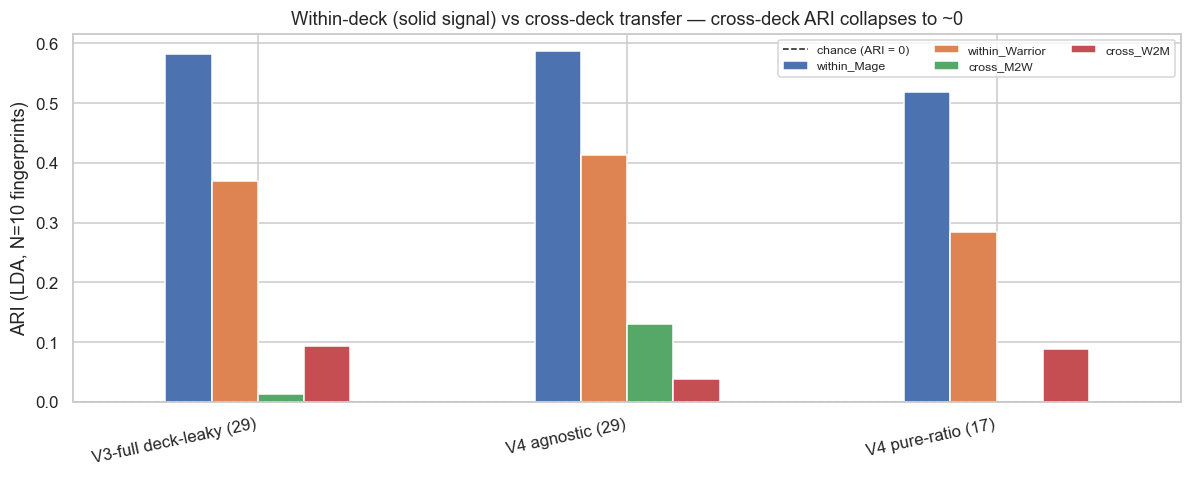

In [101]:
# R5 — §9a within-deck (reference) vs cross-deck LDA on N=10 fingerprints, scored by ARI
#      (defines FEATURE_SETS / cross_lda / _xy / DA / DB reused by R6/R6b)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from playstyle_log_parse_v4 import METRICS as V2M, TRAJ_METRICS as _TRAJ, A_FEATURES as _AF

V3_FULL  = list(V2M) + list(_TRAJ) + list(_AF)
FEATURE_SETS = {
    f"V3-full deck-leaky ({len(V3_FULL)})":      V3_FULL,
    f"V4 agnostic ({len(AGNOSTIC_FEATURES)})":   list(AGNOSTIC_FEATURES),
    f"V4 pure-ratio ({len(RATIO_FEATURES)})":    list(RATIO_FEATURES),
}
DA, DB = "RenoKazakusMage", "AggroPirateWarrior"
N_FP   = 10                                       # games averaged into one fingerprint

def _xy(df, feats, fill_from=None):
    med = (df if fill_from is None else fill_from)[feats].median()
    return df[feats].fillna(med).values, df["style"].astype(str).values

def _fingerprints(Xby, N, reps, seed):
    """Bootstrap `reps` N-game mean fingerprints per style from a {style: rows} dict."""
    r = np.random.default_rng(seed); Xs, ys = [], []
    for s in STYLE_ORDER:
        a = Xby[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(s)
    return np.array(Xs), np.array(ys)

def within_lda(feats, deck, N=N_FP):
    """Within-deck reference: split games 50/50, LDA on N-game fingerprints, ARI on the held-out half."""
    d = games_all[games_all["deck"] == deck]
    X, y = _xy(d, feats); Xs = StandardScaler().fit_transform(X)
    rng = np.random.default_rng(0); trby, teby = {}, {}
    for s in STYLE_ORDER:
        idx = np.where(y == s)[0]; rng.shuffle(idx); h = len(idx) // 2
        trby[s], teby[s] = Xs[idx[:h]], Xs[idx[h:]]
    Xa, ya = _fingerprints(trby, N, 300, 10); Xb, yb = _fingerprints(teby, N, 300, 20)
    pred = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
    return adjusted_rand_score(yb, pred)

def cross_lda(feats, a, b, N=N_FP):
    """Train deck a -> test deck b: LDA on N-game fingerprints. Returns (ARI, per-style recall dict)."""
    tr, te = games_all[games_all["deck"] == a], games_all[games_all["deck"] == b]
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    Xa, ya = _fingerprints(trby, N, 300, 10); Xb, yb = _fingerprints(teby, N, 300, 20)
    pred = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
    cm = confusion_matrix(yb, pred, labels=STYLE_ORDER, normalize="true")
    return adjusted_rand_score(yb, pred), dict(zip(STYLE_ORDER, np.diag(cm)))

rows = []
for name, feats in FEATURE_SETS.items():
    wA, wB = within_lda(feats, DA), within_lda(feats, DB)
    cAB, _ = cross_lda(feats, DA, DB)
    cBA, _ = cross_lda(feats, DB, DA)
    rows.append(dict(feature_set=name, within_Mage=wA, within_Warrior=wB,
                     cross_M2W=cAB, cross_W2M=cBA))
res = pd.DataFrame(rows).set_index("feature_set")
display(res.round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
res[["within_Mage", "within_Warrior", "cross_M2W", "cross_W2M"]].plot.bar(ax=ax)
ax.axhline(0.0, color="k", ls="--", lw=1, label="chance (ARI = 0)")
ax.set_ylabel("ARI (LDA, N=10 fingerprints)"); ax.set_xlabel("")
ax.set_title("Within-deck (solid signal) vs cross-deck transfer — cross-deck ARI collapses to ~0")
ax.set_xticklabels(ax.get_xticklabels(), rotation=12, ha="right")
ax.legend(fontsize=8, ncol=3); fig.tight_layout(); plt.show()

## R6 · Cross-deck per-style recall (heatmap)

* **From:** V4 · **both** decks · agnostic features · source §9b (cell `v4xdeck_agg`, heatmap half).
* **Model:** the **same LDA on N = 10-game fingerprints** as R5 — this heatmap is that model's
  per-style recall (the diagonal of its cross-deck confusion matrix).
* **Why a slide:** *which* styles survive a deck swap? Per-style recall (train one deck → test the
  other, both directions) shows **only the slow archetypes — `fatigue` and `ramp` — transfer**;
  `aggro`/`midrange`/`control` collapse. On the all-out Pirate Warrior deck almost everything reads
  as aggro/ramp, and midrange is the mushy middle on both decks.
* **Depends on R5** (`FEATURE_SETS`, `cross_lda`, `DA/DB`).

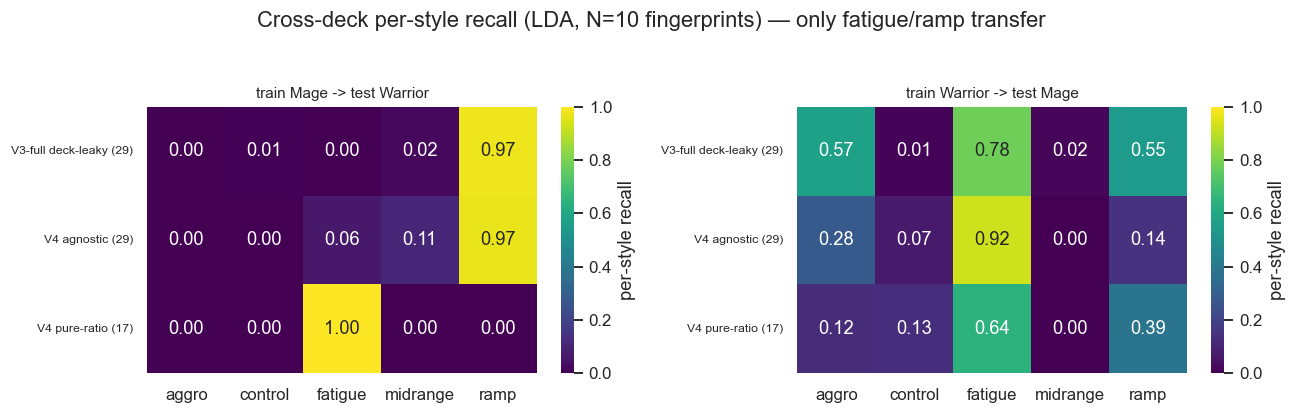

In [102]:
# R6 — §9b cross-deck per-style recall heatmaps: the same LDA on N=10 fingerprints as R5
#      (per-style recall = diagonal of that model's cross-deck confusion matrix)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (a, b, ttl) in zip(axes, [(DA, DB, "train Mage -> test Warrior"),
                                  (DB, DA, "train Warrior -> test Mage")]):
    rec = {name: cross_lda(feats, a, b)[1] for name, feats in FEATURE_SETS.items()}
    M = pd.DataFrame(rec).T[STYLE_ORDER]
    sns.heatmap(M, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "per-style recall"})
    ax.set_title(ttl, fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
fig.suptitle("Cross-deck per-style recall (LDA, N=10 fingerprints) — only fatigue/ramp transfer", y=1.04)
fig.tight_layout(); plt.show()

## R6b · Cross-deck aggregate accuracy vs games pooled

* **From:** V4 · **both** decks · agnostic features · source §9b (cell `v4xdeck_agg`, curve half).
* **Why a slide (the clincher):** pooling *fixed everything* within a deck (R3/R4) — but here,
  pooling N games into a cross-deck fingerprint barely moves the accuracy: the curves stay far below
  the 90% line even at N=120. That proves the cross-deck failure is **bias (deck entanglement), not
  variance (noise)** — you cannot average your way out of it. This is the motivation for R6c.
* **Depends on R5.**

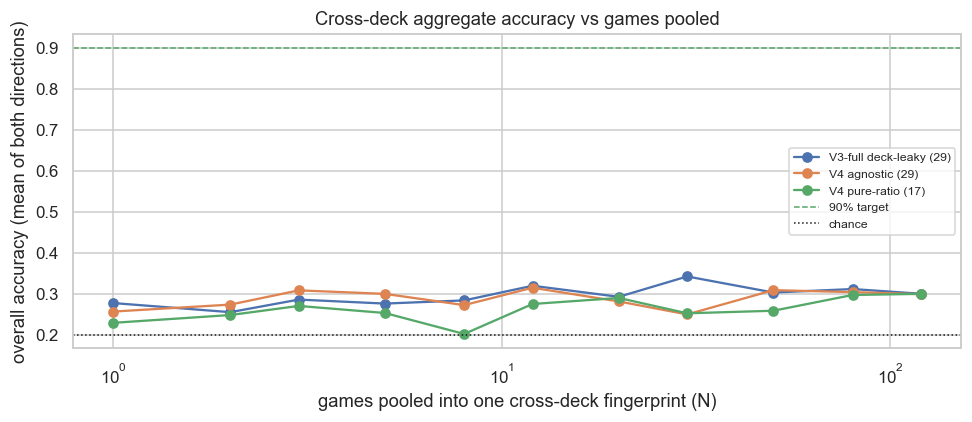

In [103]:
# R6b — §9b aggregate cross-deck accuracy vs games pooled (needs FEATURE_SETS/_xy/DA/DB from R5)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def cross_agg(feats, a, b, Ns=(1, 2, 3, 5, 8, 12, 20, 30, 50, 80, 120)):
    tr, te = games_all[games_all["deck"] == a], games_all[games_all["deck"] == b]
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    def fps(by, N, reps, seed):
        r = np.random.default_rng(seed); Xs, ys = [], []
        for si, s in enumerate(STYLE_ORDER):
            for _ in range(reps):
                Xs.append(by[s][r.integers(0, len(by[s]), N)].mean(0)); ys.append(si)
        return np.array(Xs), np.array(ys)
    out = {}
    for N in Ns:
        Xa, ya = fps(trby, N, 400, 10); Xb, yb = fps(teby, N, 400, 20)
        p = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
        out[N] = (p == yb).mean()
    return pd.Series(out)

fig, ax = plt.subplots(figsize=(9, 4))
for name, feats in FEATURE_SETS.items():
    s = (cross_agg(feats, DA, DB) + cross_agg(feats, DB, DA)) / 2
    ax.plot(s.index, s.values, marker="o", label=name)
ax.axhline(0.90, color="g", ls="--", lw=1, label="90% target")
ax.axhline(0.20, color="k", ls=":", lw=1, label="chance")
ax.set_xscale("log"); ax.set_xlabel("games pooled into one cross-deck fingerprint (N)")
ax.set_ylabel("overall accuracy (mean of both directions)")
ax.set_title("Cross-deck aggregate accuracy vs games pooled")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## R7 · RF feature importance *(optional)*

* **From:** V2 · `RenoKazakusMage` · 11 V2 metrics · source §5b (cell `c9c7484e`).
* **Why a slide (support, not spine):** a supervised sanity check that the styles *are*
  separable given labels (RF 5-fold CV well above the 0.20 chance) and — the reason it's here —
  **which metrics carry the style**. The importance bars show the load spread across several tells
  (face-attack ratio, attacks/turn, cards-in-hand, game length…) rather than resting on any single
  spine. Left: RF confusion. Middle: feature importance. Right: LDA's best linear separation.

Random-forest 5-fold CV accuracy: 0.448   (chance = 0.20)


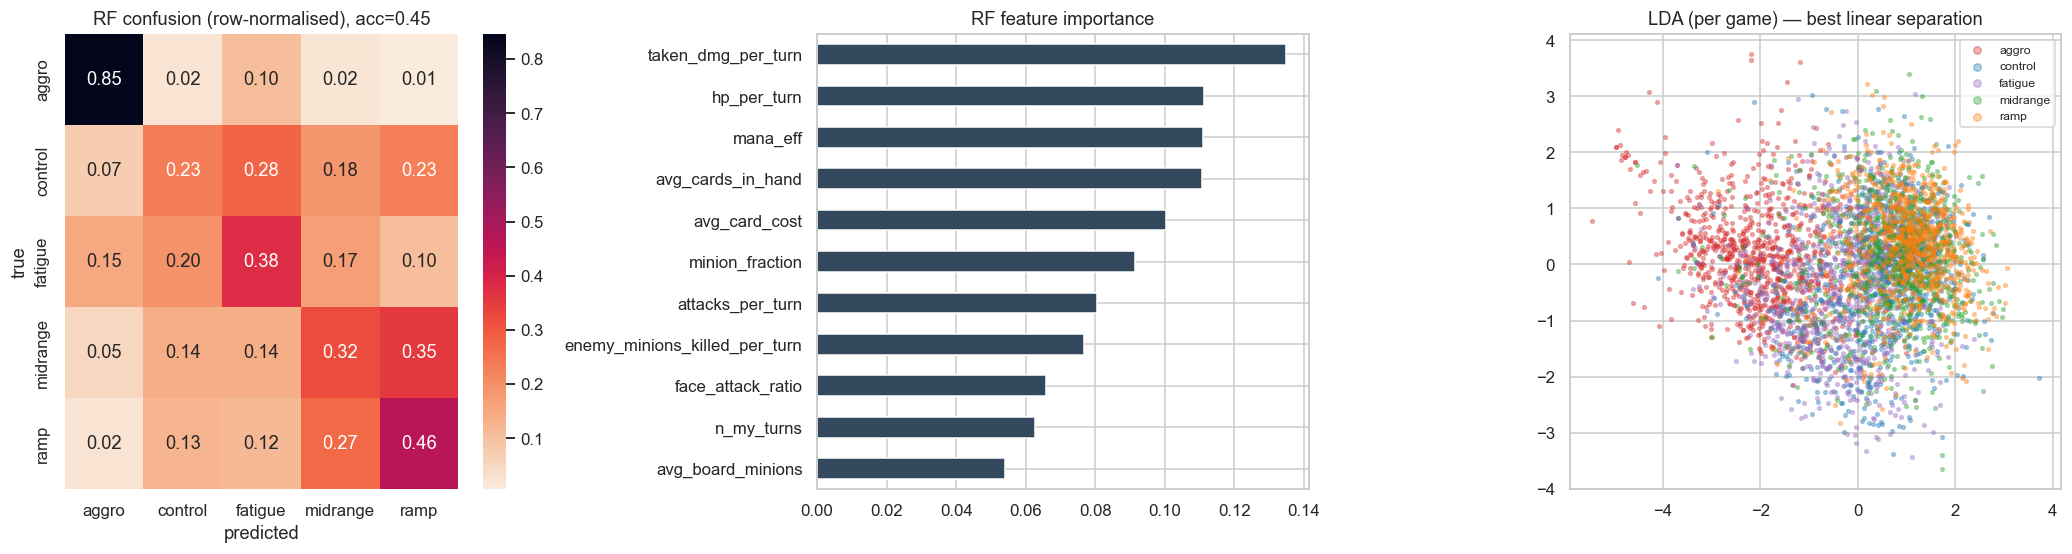

In [104]:
# R7 — §5b supervised check + RF feature importance (V2, Mage; uses X2/y2)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
pred = cross_val_predict(rf, X2, y2, cv=5)
acc = accuracy_score(y2, pred)
print(f"Random-forest 5-fold CV accuracy: {acc:.3f}   (chance = 0.20)")

rf.fit(X2, y2)
imp = pd.Series(rf.feature_importances_, index=FEATURES_V2).sort_values()
L = LinearDiscriminantAnalysis(n_components=2).fit(X2, y2).transform(X2)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
cm = confusion_matrix(y2, pred, labels=STYLE_ORDER, normalize="true")
sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[0])
ax[0].set_title(f"RF confusion (row-normalised), acc={acc:.2f}"); ax[0].set_ylabel("true"); ax[0].set_xlabel("predicted")
imp.plot.barh(ax=ax[1], color="#34495e"); ax[1].set_title("RF feature importance")
for st in STYLE_ORDER:
    m = (y2 == st); ax[2].scatter(L[m, 0], L[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[2].set_title("LDA (per game) — best linear separation"); ax[2].legend(fontsize=8, markerscale=2)
fig.tight_layout(); plt.show()

## R6c · Aggregated cross-deck: raw vs deck-normalised *(optional)*

* **From:** V4 · **both** decks · agnostic features · reviewer follow-up #3b (domain-shift correction).
* **Model / metric:** matched to R5/R6 — **LDA on N = 10-game fingerprints**, scored by **ARI**.
* **Why a slide (future-work traction):** the *first partial fix* for the R5/R6/R6b collapse. Instead of
  raw feature values, express each game as **how far it deviates from the average player of its own deck**
  (per-deck z-score). That removes the deck-level bias and lifts cross-deck ARI at N=10 from ~0.08 to
  ~0.23, with the aggregated curve reaching ~0.44 (vs ~0.22 raw) by N=120 — real traction, though
  deck-entanglement is not fully solved.
* **Left:** ARI at N=10, raw vs deck-normalised (LDA, both directions). **Right:** the same, ARI vs N.

Cross-deck ARI at N=10 fingerprints (LDA; chance ARI = 0):


,raw V4 agnostic,deck-normalised
LDA M->W,0.130,0.157
LDA W->M,0.038,0.303


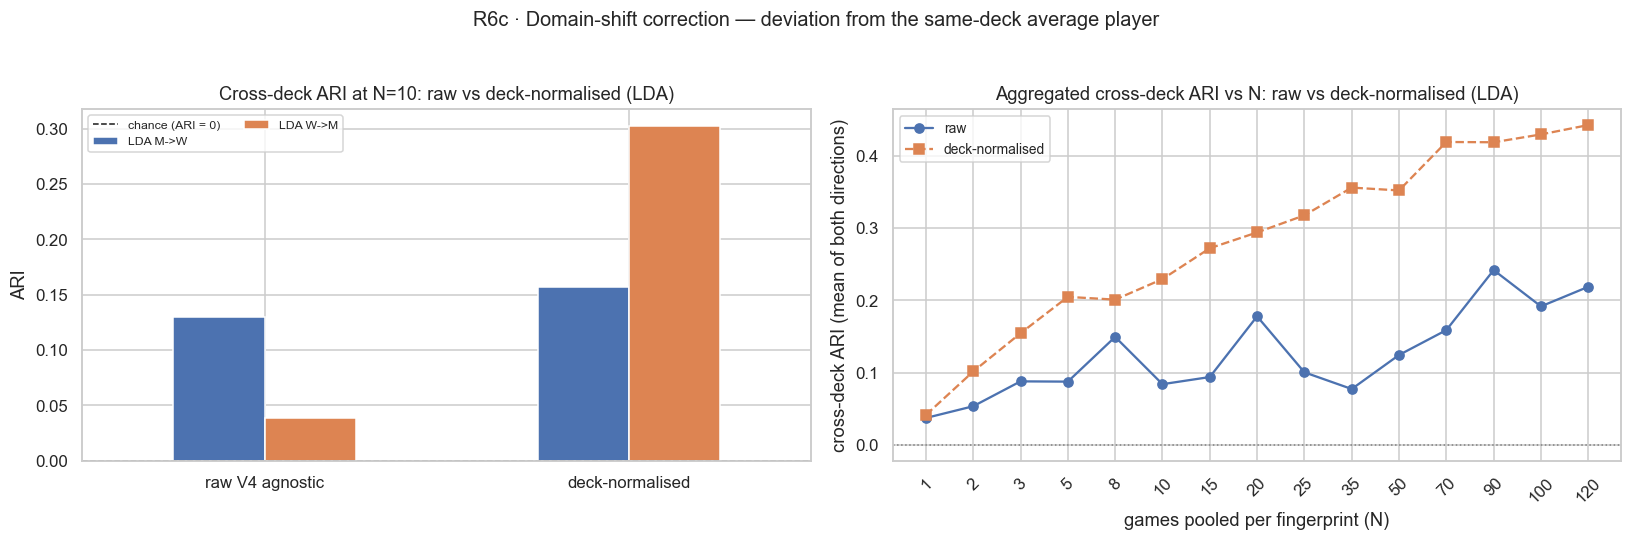

Read: per-deck z-scoring removes the deck's overall bias; cross-deck ARI rises from ~0.08 to ~0.23 at N=10 and reaches ~0.44 (vs ~0.22 raw) by N=120 — real traction, though deck-entanglement is not fully solved.


In [105]:
# R6c — reviewer #3b: domain-shift correction (standardise WITHIN each deck)  [both decks]
#      matched to R5/R6: LDA on N=10 fingerprints, scored by ARI (left = N=10 bars, right = ARI vs N)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score

DA, DB   = "RenoKazakusMage", "AggroPirateWarrior"
XFEATS   = list(AGNOSTIC_FEATURES)
N_FP     = 10                                       # games averaged into one fingerprint

def deck_zscore(df, feats):
    g = df.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median"))
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g

games_dz = deck_zscore(games_all, XFEATS)          # domain-corrected features

def _fps_dz(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for s in STYLE_ORDER:
        for _ in range(reps):
            Xs.append(by[s][r.integers(0, len(by[s]), N)].mean(0)); ys.append(s)
    return np.array(Xs), np.array(ys)

def cross_ari(frame, a, b, feats, N=N_FP, reps=300):
    """train deck a -> test deck b: LDA on N-game fingerprints, scored by ARI."""
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()                                   # impute from the TRAIN deck
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    Xa, ya = _fps_dz(trby, N, reps, 10); Xb, yb = _fps_dz(teby, N, reps, 20)
    return adjusted_rand_score(yb, LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb))

bars = {}
for label, frame in [("raw V4 agnostic", games_all), ("deck-normalised", games_dz)]:
    bars[label] = {"LDA M->W": cross_ari(frame, DA, DB, XFEATS),
                   "LDA W->M": cross_ari(frame, DB, DA, XFEATS)}
barsdf = pd.DataFrame(bars)
print("Cross-deck ARI at N=10 fingerprints (LDA; chance ARI = 0):"); display(barsdf.round(3))

def cross_agg_ari(frame, a, b, feats, Ns=(1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120), reps=300):
    tr, te = frame[frame["deck"] == a], frame[frame["deck"] == b]
    med = tr[feats].median()                                   # impute from the TRAIN deck
    Xtr, Xte = tr[feats].fillna(med).values, te[feats].fillna(med).values
    ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    out = {}
    for N in Ns:
        Xa, ya = _fps_dz(trby, N, reps, 10); Xb, yb = _fps_dz(teby, N, reps, 20)
        out[N] = adjusted_rand_score(yb, LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb))
    return pd.Series(out)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
barsdf.T.plot.bar(ax=ax[0]); ax[0].axhline(0.0, color="k", ls="--", lw=1, label="chance (ARI = 0)")
ax[0].set_title("Cross-deck ARI at N=10: raw vs deck-normalised (LDA)"); ax[0].set_ylabel("ARI")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0); ax[0].legend(fontsize=8, ncol=2)
for label, frame, ls in [("raw", games_all, "o-"), ("deck-normalised", games_dz, "s--")]:
    s = (cross_agg_ari(frame, DA, DB, XFEATS) + cross_agg_ari(frame, DB, DA, XFEATS)) / 2
    xs = range(len(s.index)); ax[1].plot(xs, s.values, ls, label=label)
ax[1].axhline(0.0, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(s.index, rotation=45)
ax[1].set_xlabel("games pooled per fingerprint (N)")
ax[1].set_ylabel("cross-deck ARI (mean of both directions)")
ax[1].set_title("Aggregated cross-deck ARI vs N: raw vs deck-normalised (LDA)"); ax[1].legend(fontsize=9)
fig.suptitle("R6c · Domain-shift correction — deviation from the same-deck average player", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("Read: per-deck z-scoring removes the deck's overall bias; cross-deck ARI rises from "
      "~0.08 to ~0.23 at N=10 and reaches ~0.44 (vs ~0.22 raw) by N=120 — real traction, "
      "though deck-entanglement is not fully solved.")

## Reading the deck end-to-end

1. **R2** — one game is ambiguous (ARI ≈ 0.09).
2. **R1 + R3** — a *player* (many games) is a sharp fingerprint (ARI → ≈ 0.99); R1 says what each looks like.
3. **R4** — so “how many games?” has a number: ~30 games → ~90% (richer V3-full features).
4. **R5 + R6 + R6b** — but that fingerprint is **deck-entangled**: cross-deck accuracy collapses to ~0.24,
   only `fatigue`/`ramp` transfer, and pooling can't rescue it → it's bias, not noise.
5. **R6c** — first partial fix: deck-relative (per-deck z-scored) features lift aggregated cross-deck
   ARI toward ~0.44 (vs ~0.22 raw). Fully deck-agnostic play-style inference is the open future-work item.